Implementation of subgraph using first mechanism

In [2]:
from langgraph.graph import StateGraph , START , END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
class LLMState2(TypedDict): ## Child graph
    generated_text : str
    translated_text : str

model = ChatGoogleGenerativeAI(model='gemini-2.5-flash-lite')

def translate_text(state: LLMState2):
    prompt = f"Translate the given text into Hindi language {state['generated_text']}"
    state['translated_text'] = model.invoke(prompt).content
    return {'translated_text':state['translated_text']}

builder2 = StateGraph(LLMState2)
builder2.add_node('translate_text' , translate_text)
builder2.add_edge(START , 'translate_text')
builder2.add_edge('translate_text' , END)
workflow2 = builder2.compile()

In [4]:
class LLMState1(TypedDict): ## Parents graph
    topic : str
    generated_text : str
    translated_text : str


def generated_text(state: LLMState1):
    prompt = f"Generate a short 50 lines essay on the given topic {state['topic']}"
    state['generated_text'] = model.invoke(prompt).content
    return {'generated_text':state['generated_text']}

def translated_text(state: LLMState1):
    result = workflow2.invoke({'generated_text':state['generated_text']})
    return {'translated_text':result['translated_text']}

builder1 = StateGraph(LLMState1)
builder1.add_node('generated_text' , generated_text)
builder1.add_node('translated_text' , translated_text)

builder1.add_edge(START , 'generated_text')
builder1.add_edge('generated_text' , 'translated_text')
builder1.add_edge('translated_text' , END)

workflow1 = builder1.compile()
workflow1.invoke({'topic':'India'})

{'topic': 'India',
 'generated_text': "**India: A Tapestry of Timeless Wonder**\n\nIndia, a land of ancient origins, breathes a vibrant tapestry woven from millennia of history, culture, and tradition. It is a subcontinent that defies singular definition, a kaleidoscope of experiences that captivates the soul. From the snow-capped peaks of the Himalayas in the north to the sun-drenched shores of the southern coast, its geographical diversity mirrors the richness of its human mosaic.\n\nThe very air in India hums with a unique energy. Bustling metropolises, teeming with life and innovation, stand in stark contrast to serene villages where time seems to move at a gentler pace. Ancient temples, whispering tales of gods and goddesses, share space with modern marvels of engineering and architecture. The scent of spices, incense, and blooming jasmine fills the air, a sensory symphony that awakens the senses.\n\nIndia's spiritual heart beats with a profound rhythm. Hinduism, Buddhism, Jainism

Implementation of subgraphs using second mechanism

In [1]:
from langgraph.graph import StateGraph , START , END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
class LLMState2(TypedDict): ## Child graph
    generated_text : str
    translated_text : str

model = ChatGoogleGenerativeAI(model='gemini-2.5-flash-lite')

def translate_text(state: LLMState2):
    prompt = f"Translate the given text into Hindi language {state['generated_text']}"
    state['translated_text'] = model.invoke(prompt).content
    return {'translated_text':state['translated_text']}

builder2 = StateGraph(LLMState2)
builder2.add_node('translate_text' , translate_text)
builder2.add_edge(START , 'translate_text')
builder2.add_edge('translate_text' , END)
workflow2 = builder2.compile()

In [3]:
class LLMState1(TypedDict): ## Parents graph
    topic : str
    generated_text : str
    translated_text : str


def generated_text(state: LLMState1):
    prompt = f"Generate a short 50 lines essay on the given topic {state['topic']}"
    state['generated_text'] = model.invoke(prompt).content
    return {'generated_text':state['generated_text']}


builder1 = StateGraph(LLMState1)
builder1.add_node('generated_text' , generated_text)

## Added child graph as node directly
builder1.add_node('workflow2', workflow2)

builder1.add_edge(START , 'generated_text')
builder1.add_edge('generated_text' , 'workflow2')
builder1.add_edge('workflow2' , END)

workflow1 = builder1.compile()
workflow1.invoke({'topic':'India'})

{'topic': 'India',
 'generated_text': "## India: A Tapestry of Ages and Aspirations\n\nIndia, a land where ancient rivers whisper tales of millennia and bustling metropolises hum with modern ambition, stands as a testament to the enduring spirit of humanity. Its very name evokes a kaleidoscope of images: saffron-robed ascetics meditating by the Ganges, the vibrant hues of Holi festivals, the intricate carvings of ancient temples, and the relentless energy of its IT hubs. This is a subcontinent of profound diversity, a mosaic of cultures, languages, religions, and traditions that have coexisted and evolved for thousands of years.\n\nFrom the snow-capped peaks of the Himalayas, guarding its northern frontier, to the sun-drenched beaches of its southern coast, India’s geographical canvas is as varied as its people. The fertile plains of the north, cradled by the mighty Indus and Ganges, have historically been the breadbasket of the nation, nurturing civilizations that shaped the very foun

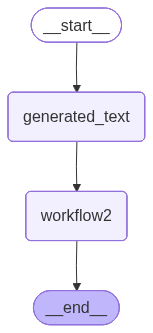

In [4]:
from IPython.display import Image
Image(workflow1.get_graph().draw_mermaid_png())